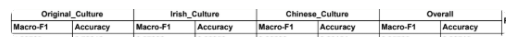

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 读取图片
img = mpimg.imread("evaluation_metric.png")

# 显示图片
plt.imshow(img)
plt.axis("off")   # 不显示坐标轴
plt.show()

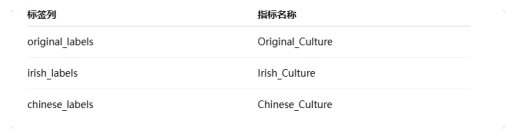

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 读取图片
img = mpimg.imread("evaluation_table.png")

# 显示图片
plt.imshow(img)
plt.axis("off")   # 不显示坐标轴
plt.show()

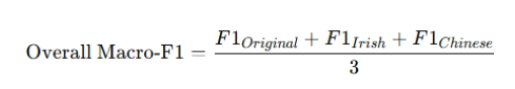

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 读取图片
img = mpimg.imread("Macro_F1_overall.png")

# 显示图片
plt.imshow(img)
plt.axis("off")   # 不显示坐标轴
plt.show()

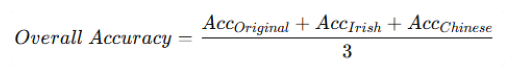

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 读取图片
img = mpimg.imread("Accuracy_overall.png")

# 显示图片
plt.imshow(img)
plt.axis("off")   # 不显示坐标轴
plt.show()

和任务说明完全一致。

Gemma-3-1B-it-abliterated

In [11]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

# =========================
# 1. 读取文件
# =========================
# 真实标签文件
true_df = pd.read_csv("dataset/Tamil/test/test-with-labels.csv")

# 预测结果文件
pred_df = pd.read_csv("Gemma-3-1B-it-abliterated/tamil/wangkongqiang_taskb_tamil.csv")


# =========================
# 2. 查看列名（建议先打印）
# =========================
print("True columns:", true_df.columns.tolist())
print("Pred columns:", pred_df.columns.tolist())


True columns: ['image_id', 'transcriptions', 'original_labels', 'irish_labels', 'chinese_labels']
Pred columns: ['image_id', 'original_culture', 'irish_culture', 'chinese_culture']


In [14]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

# ======================================
# 1. 读取真实标签和预测结果
# ======================================

true_df = pd.read_csv("dataset/Tamil/test/test-with-labels.csv")
pred_df = pd.read_csv("Gemma-3-1B-it-abliterated/tamil/wangkongqiang_taskb_tamil.csv")


# ======================================
# 2. 标签映射
# 1 -> misogyny
# 0 -> not-misogyny
# ======================================

label_map = {
    "misogyny": 1,
    "not-misogyny": 0 
}

# --------------------------------------
# 真实标签映射
# --------------------------------------

true_df["original_labels"] = true_df["original_labels"].map(label_map)
true_df["irish_labels"] = true_df["irish_labels"].map(label_map)
true_df["chinese_labels"] = true_df["chinese_labels"].map(label_map)

# --------------------------------------
# 预测标签映射
# --------------------------------------

pred_df["original_labels"] = pred_df["original_culture"]
pred_df["irish_labels"] = pred_df["irish_culture"]
pred_df["chinese_labels"] = pred_df["chinese_culture"]


# ======================================
# 3. 定义评测函数
# ======================================

def calculate_metrics(y_true, y_pred):

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    return macro_f1, accuracy


# ======================================
# 4. 分文化计算指标
# ======================================

results = {}

culture_mapping = {
    "Original_Culture": "original_labels",
    "Irish_Culture": "irish_labels",
    "Chinese_Culture": "chinese_labels"
}

macro_f1_list = []
accuracy_list = []

for culture_name, label_col in culture_mapping.items():

    y_true = true_df[label_col]
    y_pred = pred_df[label_col]

    print("y_true:",y_true)
    print("y_pred:",y_pred)
    macro_f1, accuracy = calculate_metrics(y_true, y_pred)

    results[culture_name] = {
        "Macro-F1": macro_f1,
        "Accuracy": accuracy
    }

    macro_f1_list.append(macro_f1)
    accuracy_list.append(accuracy)


# ======================================
# 5. Overall 指标
# ======================================

overall_macro_f1 = sum(macro_f1_list) / 3
overall_accuracy = sum(accuracy_list) / 3

results["Overall"] = {
    "Macro-F1": overall_macro_f1,
    "Accuracy": overall_accuracy
}


# ======================================
# 6. 输出结果
# ======================================

print("\n========== Evaluation Results ==========\n")

for culture, metrics in results.items():

    print(f"{culture}")
    print(f"Macro-F1 : {metrics['Macro-F1']:.4f}")
    print(f"Accuracy : {metrics['Accuracy']:.4f}")
    print("-" * 40)


# ======================================
# 7. 转成表格输出（可选）
# ======================================

result_df = pd.DataFrame(results).T

print("\nFinal Result Table:\n")
print(result_df)

y_true: 0      1
1      0
2      1
3      0
4      0
      ..
351    0
352    1
353    0
354    0
355    1
Name: original_labels, Length: 356, dtype: int64
y_pred: 0      0
1      0
2      0
3      0
4      0
      ..
351    0
352    0
353    0
354    0
355    0
Name: original_labels, Length: 356, dtype: int64
y_true: 0      1
1      0
2      1
3      0
4      0
      ..
351    0
352    0
353    0
354    0
355    0
Name: irish_labels, Length: 356, dtype: int64
y_pred: 0      1
1      0
2      0
3      0
4      0
      ..
351    0
352    0
353    0
354    0
355    0
Name: irish_labels, Length: 356, dtype: int64
y_true: 0      0
1      0
2      1
3      0
4      0
      ..
351    0
352    0
353    0
354    0
355    1
Name: chinese_labels, Length: 356, dtype: int64
y_pred: 0      0
1      0
2      0
3      0
4      0
      ..
351    0
352    0
353    0
354    0
355    0
Name: chinese_labels, Length: 356, dtype: int64

========== Evaluation Results ==========

Original_Culture
Macro-F1 : 0

Gemma-3-4B-it-abliterated

In [15]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

# ======================================
# 1. 读取真实标签和预测结果
# ======================================

true_df = pd.read_csv("dataset/Tamil/test/test-with-labels.csv")
pred_df = pd.read_csv("Gemma-3-4B-it-abliterated/tamil/wangkongqiang_taskb_tamil.csv")


# ======================================
# 2. 标签映射
# 1 -> misogyny
# 0 -> not-misogyny
# ======================================

label_map = {
    "misogyny": 1,
    "not-misogyny": 0 
}

# --------------------------------------
# 真实标签映射
# --------------------------------------

true_df["original_labels"] = true_df["original_labels"].map(label_map)
true_df["irish_labels"] = true_df["irish_labels"].map(label_map)
true_df["chinese_labels"] = true_df["chinese_labels"].map(label_map)

# --------------------------------------
# 预测标签映射
# --------------------------------------

pred_df["original_labels"] = pred_df["original_culture"]
pred_df["irish_labels"] = pred_df["irish_culture"]
pred_df["chinese_labels"] = pred_df["chinese_culture"]


# ======================================
# 3. 定义评测函数
# ======================================

def calculate_metrics(y_true, y_pred):

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    return macro_f1, accuracy


# ======================================
# 4. 分文化计算指标
# ======================================

results = {}

culture_mapping = {
    "Original_Culture": "original_labels",
    "Irish_Culture": "irish_labels",
    "Chinese_Culture": "chinese_labels"
}

macro_f1_list = []
accuracy_list = []

for culture_name, label_col in culture_mapping.items():

    y_true = true_df[label_col]
    y_pred = pred_df[label_col]

    print("y_true:",y_true)
    print("y_pred:",y_pred)
    macro_f1, accuracy = calculate_metrics(y_true, y_pred)

    results[culture_name] = {
        "Macro-F1": macro_f1,
        "Accuracy": accuracy
    }

    macro_f1_list.append(macro_f1)
    accuracy_list.append(accuracy)


# ======================================
# 5. Overall 指标
# ======================================

overall_macro_f1 = sum(macro_f1_list) / 3
overall_accuracy = sum(accuracy_list) / 3

results["Overall"] = {
    "Macro-F1": overall_macro_f1,
    "Accuracy": overall_accuracy
}


# ======================================
# 6. 输出结果
# ======================================

print("\n========== Evaluation Results ==========\n")

for culture, metrics in results.items():

    print(f"{culture}")
    print(f"Macro-F1 : {metrics['Macro-F1']:.4f}")
    print(f"Accuracy : {metrics['Accuracy']:.4f}")
    print("-" * 40)


# ======================================
# 7. 转成表格输出（可选）
# ======================================

result_df = pd.DataFrame(results).T

print("\nFinal Result Table:\n")
print(result_df)

y_true: 0      1
1      0
2      1
3      0
4      0
      ..
351    0
352    1
353    0
354    0
355    1
Name: original_labels, Length: 356, dtype: int64
y_pred: 0      1
1      0
2      0
3      0
4      1
      ..
351    0
352    1
353    1
354    0
355    1
Name: original_labels, Length: 356, dtype: int64
y_true: 0      1
1      0
2      1
3      0
4      0
      ..
351    0
352    0
353    0
354    0
355    0
Name: irish_labels, Length: 356, dtype: int64
y_pred: 0      0
1      0
2      0
3      0
4      1
      ..
351    0
352    1
353    1
354    0
355    1
Name: irish_labels, Length: 356, dtype: int64
y_true: 0      0
1      0
2      1
3      0
4      0
      ..
351    0
352    0
353    0
354    0
355    1
Name: chinese_labels, Length: 356, dtype: int64
y_pred: 0      0
1      0
2      0
3      0
4      1
      ..
351    0
352    1
353    1
354    0
355    1
Name: chinese_labels, Length: 356, dtype: int64

========== Evaluation Results ==========

Original_Culture
Macro-F1 : 0

Qwen2.5-VL-3B-Instruct

In [16]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

# ======================================
# 1. 读取真实标签和预测结果
# ======================================

true_df = pd.read_csv("dataset/Tamil/test/test-with-labels.csv")
pred_df = pd.read_csv("Qwen2.5-VL-3B-Instruct/tamil/wangkongqiang_taskb_tamil.csv")


# ======================================
# 2. 标签映射
# 1 -> misogyny
# 0 -> not-misogyny
# ======================================

label_map = {
    "misogyny": 1,
    "not-misogyny": 0 
}

# --------------------------------------
# 真实标签映射
# --------------------------------------

true_df["original_labels"] = true_df["original_labels"].map(label_map)
true_df["irish_labels"] = true_df["irish_labels"].map(label_map)
true_df["chinese_labels"] = true_df["chinese_labels"].map(label_map)

# --------------------------------------
# 预测标签映射
# --------------------------------------

pred_df["original_labels"] = pred_df["original_culture"]
pred_df["irish_labels"] = pred_df["irish_culture"]
pred_df["chinese_labels"] = pred_df["chinese_culture"]


# ======================================
# 3. 定义评测函数
# ======================================

def calculate_metrics(y_true, y_pred):

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    return macro_f1, accuracy


# ======================================
# 4. 分文化计算指标
# ======================================

results = {}

culture_mapping = {
    "Original_Culture": "original_labels",
    "Irish_Culture": "irish_labels",
    "Chinese_Culture": "chinese_labels"
}

macro_f1_list = []
accuracy_list = []

for culture_name, label_col in culture_mapping.items():

    y_true = true_df[label_col]
    y_pred = pred_df[label_col]

    print("y_true:",y_true)
    print("y_pred:",y_pred)
    macro_f1, accuracy = calculate_metrics(y_true, y_pred)

    results[culture_name] = {
        "Macro-F1": macro_f1,
        "Accuracy": accuracy
    }

    macro_f1_list.append(macro_f1)
    accuracy_list.append(accuracy)


# ======================================
# 5. Overall 指标
# ======================================

overall_macro_f1 = sum(macro_f1_list) / 3
overall_accuracy = sum(accuracy_list) / 3

results["Overall"] = {
    "Macro-F1": overall_macro_f1,
    "Accuracy": overall_accuracy
}


# ======================================
# 6. 输出结果
# ======================================

print("\n========== Evaluation Results ==========\n")

for culture, metrics in results.items():

    print(f"{culture}")
    print(f"Macro-F1 : {metrics['Macro-F1']:.4f}")
    print(f"Accuracy : {metrics['Accuracy']:.4f}")
    print("-" * 40)


# ======================================
# 7. 转成表格输出（可选）
# ======================================

result_df = pd.DataFrame(results).T

print("\nFinal Result Table:\n")
print(result_df)

y_true: 0      1
1      0
2      1
3      0
4      0
      ..
351    0
352    1
353    0
354    0
355    1
Name: original_labels, Length: 356, dtype: int64
y_pred: 0      1
1      1
2      1
3      1
4      1
      ..
351    1
352    1
353    1
354    1
355    1
Name: original_labels, Length: 356, dtype: int64
y_true: 0      1
1      0
2      1
3      0
4      0
      ..
351    0
352    0
353    0
354    0
355    0
Name: irish_labels, Length: 356, dtype: int64
y_pred: 0      1
1      1
2      1
3      1
4      1
      ..
351    1
352    1
353    1
354    1
355    1
Name: irish_labels, Length: 356, dtype: int64
y_true: 0      0
1      0
2      1
3      0
4      0
      ..
351    0
352    0
353    0
354    0
355    1
Name: chinese_labels, Length: 356, dtype: int64
y_pred: 0      1
1      1
2      1
3      1
4      1
      ..
351    1
352    1
353    1
354    1
355    1
Name: chinese_labels, Length: 356, dtype: int64

========== Evaluation Results ==========

Original_Culture
Macro-F1 : 0

Qwen2.5-VL-7B-Instruct

In [17]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

# ======================================
# 1. 读取真实标签和预测结果
# ======================================

true_df = pd.read_csv("dataset/Tamil/test/test-with-labels.csv")
pred_df = pd.read_csv("Qwen2.5-VL-7B-Instruct/tamil/wangkongqiang_taskb_tamil.csv")


# ======================================
# 2. 标签映射
# 1 -> misogyny
# 0 -> not-misogyny
# ======================================

label_map = {
    "misogyny": 1,
    "not-misogyny": 0 
}

# --------------------------------------
# 真实标签映射
# --------------------------------------

true_df["original_labels"] = true_df["original_labels"].map(label_map)
true_df["irish_labels"] = true_df["irish_labels"].map(label_map)
true_df["chinese_labels"] = true_df["chinese_labels"].map(label_map)

# --------------------------------------
# 预测标签映射
# --------------------------------------

pred_df["original_labels"] = pred_df["original_culture"]
pred_df["irish_labels"] = pred_df["irish_culture"]
pred_df["chinese_labels"] = pred_df["chinese_culture"]


# ======================================
# 3. 定义评测函数
# ======================================

def calculate_metrics(y_true, y_pred):

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    return macro_f1, accuracy


# ======================================
# 4. 分文化计算指标
# ======================================

results = {}

culture_mapping = {
    "Original_Culture": "original_labels",
    "Irish_Culture": "irish_labels",
    "Chinese_Culture": "chinese_labels"
}

macro_f1_list = []
accuracy_list = []

for culture_name, label_col in culture_mapping.items():

    y_true = true_df[label_col]
    y_pred = pred_df[label_col]

    print("y_true:",y_true)
    print("y_pred:",y_pred)
    macro_f1, accuracy = calculate_metrics(y_true, y_pred)

    results[culture_name] = {
        "Macro-F1": macro_f1,
        "Accuracy": accuracy
    }

    macro_f1_list.append(macro_f1)
    accuracy_list.append(accuracy)


# ======================================
# 5. Overall 指标
# ======================================

overall_macro_f1 = sum(macro_f1_list) / 3
overall_accuracy = sum(accuracy_list) / 3

results["Overall"] = {
    "Macro-F1": overall_macro_f1,
    "Accuracy": overall_accuracy
}


# ======================================
# 6. 输出结果
# ======================================

print("\n========== Evaluation Results ==========\n")

for culture, metrics in results.items():

    print(f"{culture}")
    print(f"Macro-F1 : {metrics['Macro-F1']:.4f}")
    print(f"Accuracy : {metrics['Accuracy']:.4f}")
    print("-" * 40)


# ======================================
# 7. 转成表格输出（可选）
# ======================================

result_df = pd.DataFrame(results).T

print("\nFinal Result Table:\n")
print(result_df)

y_true: 0      1
1      0
2      1
3      0
4      0
      ..
351    0
352    1
353    0
354    0
355    1
Name: original_labels, Length: 356, dtype: int64
y_pred: 0      1
1      0
2      1
3      0
4      1
      ..
351    1
352    1
353    1
354    1
355    1
Name: original_labels, Length: 356, dtype: int64
y_true: 0      1
1      0
2      1
3      0
4      0
      ..
351    0
352    0
353    0
354    0
355    0
Name: irish_labels, Length: 356, dtype: int64
y_pred: 0      1
1      0
2      1
3      0
4      1
      ..
351    1
352    1
353    1
354    1
355    1
Name: irish_labels, Length: 356, dtype: int64
y_true: 0      0
1      0
2      1
3      0
4      0
      ..
351    0
352    0
353    0
354    0
355    1
Name: chinese_labels, Length: 356, dtype: int64
y_pred: 0      1
1      0
2      1
3      0
4      1
      ..
351    1
352    1
353    1
354    1
355    1
Name: chinese_labels, Length: 356, dtype: int64

========== Evaluation Results ==========

Original_Culture
Macro-F1 : 0